# BERDO Compliance Analysis

**Identifying High-Impact Energy Reduction Opportunities in Boston Buildings**

## Tools Used
- Python  
- pandas  
- matplotlib  

## Introduction

This project analyzes BERDO compliance data for Boston buildings to evaluate how energy performance and building characteristics relate to compliance outcomes.

The analysis focuses on identifying patterns in Energy Use Intensity (EUI), property type, and emissions to understand which buildings are more likely to meet compliance requirements. It also highlights gaps in reporting and performance that may indicate where additional support or intervention is needed.

By combining data cleaning, exploratory analysis, and comparative metrics, this project provides insight into where the greatest opportunities exist for reducing energy use and improving compliance across Boston’s building stock.

## Key Insight
Buildings with higher energy use intensity (EUI) tend to fall into more complex compliance pathways, indicating that energy-intensive buildings represent the greatest opportunity for targeted emissions reduction.


## Data Loading and Preparation

Data was imported using Python (pandas) and cleaned to standardize column names and improve usability.
Key preprocessing steps included:
- Converting column names to lowercase and replacing spaces with underscores
- Renaming key variables (e.g., property type, energy use intensity, emissions) for clarity
- Removing records with missing values in critical fields such as site EUI


## Feature Selection

The analysis focuses on variables directly related to compliance and energy performance:
- Property type
- Site Energy Use Intensity (EUI)
- Total energy usage
- Greenhouse gas (GHG) emissions
- Compliance status

## Analysis Approach

The analysis includes:
- Descriptive statistics to examine compliance distribution
- Frequency analysis of building types
- Visualization of compliance status using bar charts
- Grouped analysis comparing average EUI across compliance categories
- Correlation analysis between building size and energy intensity

## Libraries

In [108]:
#Section 1. Load libraries
import pandas as pd
import os
import matplotlib.pyplot as plt

#file path
file_path = os.path.expanduser("/Users/ryan/Documents/BERDO Compliance/2025-reported-energy-and-water-metrics.xlsx")

#Section 2. Load dataset
df = pd.read_excel(file_path, header=1)

##Section 3. Initial data inspection
df.shape
df.columns
df.head().style.hide(axis = "index")

BERDO ID,Tax Parcel ID,Property Owner Name,Building Address,Building Address City,Building Address Zip Code,Parcel Address,Parcel Address City,Parcel Address Zip Code,Reported Gross Floor Area (Sq Ft),Reported Enclosed Parking Area (Sq Ft),BERDO Emissions Gross Floor Area (Sq Ft),Largest Property Type,All Property Types and GFAs,Total Site Energy Usage (kBtu),Energy Star Score,Site EUI (Energy Use Intensity kBtu/ft²),Natural Gas Usage (kBtu),Natural Gas Emissions (kgCO2e),Electricity Usage (kWh),Electricity Emissions (kgCO2e),Renewable System Electricity Usage Onsite (kBtu),District Hot Water Usage (kBtu),District Hot Water Emissions (kgCO2e),District Chilled Water Usage (kBtu),District Chilled Water Emissions (kgCO2e),District Steam Usage (kBtu),District Steam Emissions (kgCO2e),Fuel Oil 1 Usage (kBtu),Fuel Oil 1 Emissions (kgCO2e),Fuel Oil 2 Usage (kBtu),Fuel Oil 2 Emissions (kgCO2e),Fuel Oil 4 Usage (kBtu),Fuel Oil 4 Emissions (kgCO2e),Fuel Oil 5 and 6 Usage (kBtu),Fuel Oil 5 and 6 Emissions (kgCO2e),Propane Usage (kBtu),Propane Emissions (kgCO2e),Diesel Usage (kBtu),Diesel Emissions (kgCO2e),Kerosene Usage (kBtu),Kerosene Emissions (kgCO2e),Water Usage Intensity (Gallons/ft²),Estimated Total GHG Emissions (kgCO2e),Reporting Compliance Status,First Emissions Compliance Year (Projected),Community Choice Electricity Participation,Renewable Energy Purchased through a Power Purchase Agreement (PPA),Renewable Energy Certificate (REC) Purchase,Backup Generator,Battery Storage,Electric Vehicle (EV) Charging,Corresponding Campus ID,Notes
100001,303060001,1 LOVEJOY WHARF BOSTON REALTY LLC,nan,Boston,2114.000000,160 170 N Washington St,Boston,2114.000000,251688.000000,nan,251688.000000,Office,"Food Sales (15000),Office (231408),Retail Store (5280)",17843015.400000,62.000000,70.900000,4939583.900000,262341.301000,3781779.500000,735783.020000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,10.640000,998124.321000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100002,304794000,10 TEMPLE PLACE LP,2-24 Temple Pl,Boston,2111.000000,24 2 Temple Pl,Boston,2111.000000,135344.000000,nan,135344.000000,Multifamily Housing,"Personal Services (Health/Beauty, Dry Cleaning, etc) (1129),Restaurant (1552),Multifamily Housing (127684),Medical Office (2145),Supermarket/Grocery Store (2834)",7527620.000000,nan,55.600000,4933261.400000,262005.513000,760363.000000,147936.225000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,36.720000,409941.738000,in compliance,2025.000000,Unsure,No,No,Yes,No,No,nan,nan
100003,602757045,10-20 CHANNEL CENTER,20 Channel Center St,Boston,2127.000000,20 30 Channel Center St,Boston,2127.000000,255383.000000,nan,255383.000000,Office,Office (255383),11674291.400000,62.000000,45.700000,nan,nan,3421539.100000,665694.647000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,7.230000,665694.647000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100005,304718000,10-24 SCHOOL STREET,24 School St,Boston,2108.000000,12 Province St,Boston,2108.000000,134789.000000,nan,134789.000000,Office,"Office (108140),Data Center (361),Retail Store (26288)",7580836.800000,82.000000,56.200000,nan,nan,1098218.100000,213669.314000,nan,nan,nan,nan,nan,3833716.600000,226572.651000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,5.360000,440241.965000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100007,304408000,100 HIGH OWNER LLC,100 High St,Boston,2110.000000,100 High St,Boston,2110.000000,551954.000000,94644.000000,646598.000000,Office,"Office (541668),Data Center (400),Other - Restaurant/Bar (9886),Parking (94644)",27164780.800000,79.000000,49.200000,nan,nan,7961541.800000,1548997.573000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,6.430000,1548997.573000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan


Data

## Column Cleaning

In [109]:
#load original dataset

df_full = pd.read_excel(file_path, header=1)

df_full.columns = (
    df_full.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
)

df_full = pd.read_excel(file_path, header=1)

In [122]:
#Section 4. Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
)

#view cleaned column names
pd.DataFrame(df.columns, columns = ["cleaned_columns"]).style.hide(axis = "index")

cleaned_columns
berdo_id
tax_parcel_id
property_owner_name
building_address
building_address_city
building_address_zip__code
parcel_address
parcel_address_city
parcel_address_zip_code
gross_floor_area


## Rename columns

In [112]:
#Section 5. Rename key variables
df = df.rename(columns={
    "largest_property_type": "property_type",
    "reported_gross_floor_area_(sq_ft)": "gross_floor_area",
    "site_eui_(energy_use_intensity_kbtu_ft²)": "site_eui",
    "total_site_energy_usage_(kbtu)": "total_site_energy",
    "estimated_total_ghg_emissions_(kgco2e)": "ghg_emissions",
    "natural_gas_usage_(kbtu)": "natural_gas_usage",
    "electricity_usage_(kwh)": "electricity_usage",
    "reporting_compliance_status": "compliance_status",
    "first_emissions_compliance_year_(projected)": "compliance_year"
})

#Section 6. Handle missing values
df = df.dropna(subset=["site_eui"])

#preview core analysis fields
df[["property_type", "site_eui", "compliance_status"]].head()

,property_type,site_eui,compliance_status
0,Office,70.9,in compliance
1,Multifamily Housing,55.6,in compliance
2,Office,45.7,in compliance
3,Office,56.2,in compliance
4,Office,49.2,in compliance


In [113]:
#Section 7.Verify cleaned dataset

subset = df[["property_type", "site_eui", "compliance_status"]]

subset.head().style\
    .hide(axis="index")\
    .set_caption("Preview of Core Analysis Fields")\
    .set_properties(**{"text-align": "center"})\
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]}
    ])

property_type,site_eui,compliance_status
Office,70.900000,in compliance
Multifamily Housing,55.600000,in compliance
Office,45.700000,in compliance
Office,56.200000,in compliance
Office,49.200000,in compliance


### Observation

The dataset preview confirms that key variables such as property type, site EUI, and compliance status have been successfully cleaned and standardized, ensuring consistency and enabling reliable comparative analysis across building categories.

## Analysis

## Features Used
The analysis focuses on variables directly related to compliance and energy performance:
- Property type
- Site Energy Use Intensity (EUI)
- Total energy usage
- Greenhouse gas (GHG) emissions
- Compliance status

In [116]:
df_full.columns = (
    df_full.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
)

In [117]:
#rename column in full dataset
df_full = df_full.rename(columns={
    "reporting_compliance_status": "compliance_status"
})

#Section 8. Compliance distribution

compliance_table = (
    df_full["compliance_status"]
    .value_counts()
    .rename_axis("compliance_status")
    .reset_index(name="count")
)

#add percentage
compliance_table["percent"] = (
    compliance_table["count"] / compliance_table["count"].sum()
)

#styled output
compliance_table.style\
    .hide(axis="index")\
    .set_caption("BERDO Compliance Distribution (2025)")\
    .format({
        "count": "{:,}",
        "percent": "{:.1%}"
    })

compliance_status,count,percent
in compliance,"3,569",65.0%
not submitted,"1,579",28.8%
pending revisions,223,4.1%
state,116,2.1%


### Observation

The dataset is heavily concentrated in the “in compliance” category (3,412 buildings) with significantly fewer buildings in “pending revisions” (150) and “state” pathways (34). 

This imbalance indicates that while overall compliance rates are high, a small subset of buildings may represent disproportionately complex or resource-intensive cases requiring additional attention.

In [118]:
#Section 9. Property type distribution

property_table = (
    df["property_type"]
    .value_counts()
    .head(10)
    .rename_axis("Property Type")
    .reset_index(name = "Count")
)

property_table.style.hide(axis = "index")

Property Type,Count
Multifamily Housing,2052
Office,425
College/University,245
K-12 School,163
Hotel,66
Laboratory,48
Worship Facility,37
Fire Station,33
Other - Recreation,32
Manufacturing/Industrial Plant,30


### Observation

Multifamily Housing is the main building type of the dataset (2,052 buildings), followed by Office buildings (425), with all other property types appearing in significantly smaller numbers.
This distribution indicates that BERDO compliance activity is heavily concentrated in residential buildings, while institutional and specialized properties (e.g., schools, laboratories, industrial facilities) represent a much smaller share of the dataset.

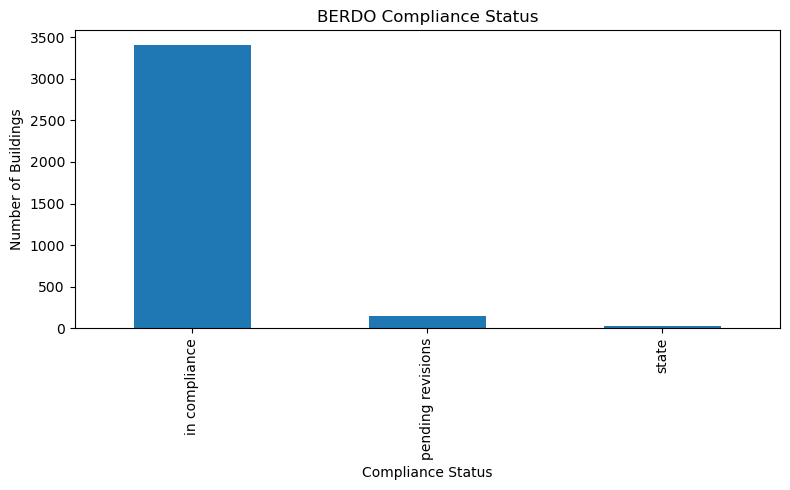

In [119]:
#Section 10. Visualization compliance status

plt.figure(figsize=(8,5))
df["compliance_status"].value_counts().plot(kind="bar")
plt.title("BERDO Compliance Status")
plt.xlabel("Compliance Status")
plt.ylabel("Number of Buildings")
plt.tight_layout()
plt.show()

## Average EUI by Compliance

In [120]:
#Section 11. Energy performance by compliance status

#average eui by compliance status
eui_by_compliance = (
    df.groupby("compliance_status")["site_eui"]
    .mean()
    .rename("average_eui")
    .reset_index()
    .sort_values(by="average_eui", ascending=False)
    .reset_index(drop = True)
)

eui_by_compliance.style.hide(axis = "index")

compliance_status,average_eui
state,92.032353
in compliance,76.413746
pending revisions,73.992000


### Observation

Buildings under the state compliance pathway have the highest average Site EUI (approximately 92), indicating they are the most energy-intensive group. In contrast, buildings that are in compliance (approximately 76) and those with pending revisions (approximately 74) show lower and similar energy intensity levels.

This suggests that higher-energy buildings may face greater challenges in meeting BERDO requirements and may require more complex compliance strategies, while lower-energy buildings are more likely to achieve compliance with fewer barriers.

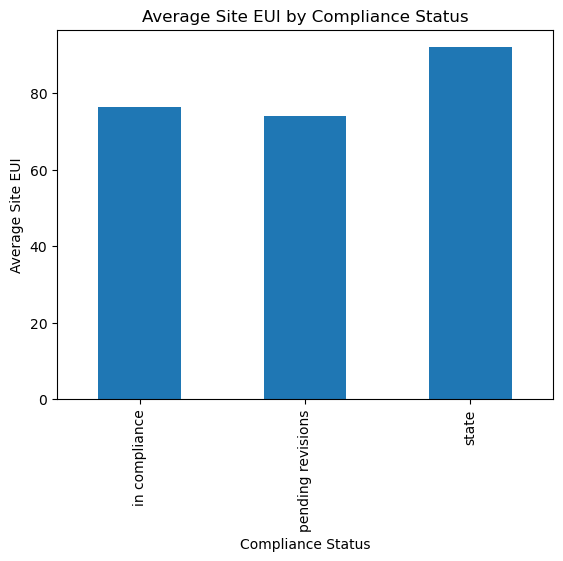

In [121]:
#Section 12.Correlation analysis

df[["gross_floor_area", "site_eui"]].corr()

ax = df.groupby("compliance_status")["site_eui"].mean().plot(kind="bar")

ax.set_title("Average Site EUI by Compliance Status")
ax.set_xlabel("Compliance Status")
ax.set_ylabel("Average Site EUI");

## Conclusion

This analysis shows that BERDO compliance is closely tied to energy performance. Buildings with higher Site EUI, particularly those under state pathways, represent the largest opportunity for energy reduction.

Focusing on these high-intensity buildings through targeted efficiency improvements, technical support, and policy interventions could have the greatest impact on improving compliance outcomes across Boston’s building stock.